In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# imput data files are available in the read-only "../input/" directory
# for example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [3]:
df = pd.read_csv('PS_20174392719_1491204439457_log.csv')
df.head()  
# first five rows of dataset

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:

# df = df.sort_values(by=['nameDest', 'step'])
# df['transactions_last_6hrs_dest'] = df.groupby('nameDest')['step'].transform(lambda x: x.rolling(6, min_periods=1).count())

# df = df.sort_values(by=['nameOrig', 'step'])
# df['transactions_last_6hrs_orig'] = df.groupby('nameOrig')['step'].transform(lambda x: x.rolling(6, min_periods=1).count())


# df['high_freq_dest'] = (df['transactions_last_6hrs_dest'] > 5).astype(int)
# df['high_freq_orig'] = (df['transactions_last_6hrs_orig'] > 5).astype(int)
# # --- End of New Features ---

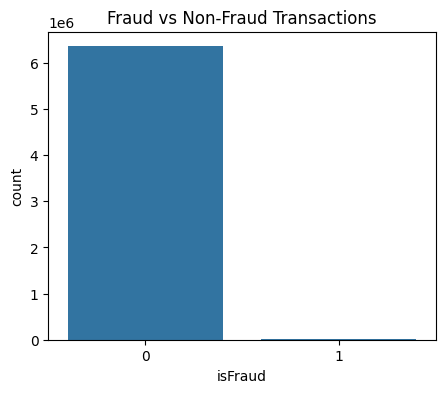

In [5]:
plt.figure(figsize=(5,4))
sns.countplot(x='isFraud', data=df)
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

In [6]:
# df.info()

In [7]:
# last five rows of dataset
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [8]:
df.shape    

(6362620, 11)

In [9]:
# checking the frequnency of each values in each column
df['type'].value_counts()
# jese cash_out, transfer, etc. kitne baar aaye hain

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [10]:
print("\n--- Target Variable Distribution (isFraud) ---")
print(df['isFraud'].value_counts())
print(df['isFraud'].value_counts(normalize=True) * 100)


--- Target Variable Distribution (isFraud) ---
isFraud
0    6354407
1       8213
Name: count, dtype: int64
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


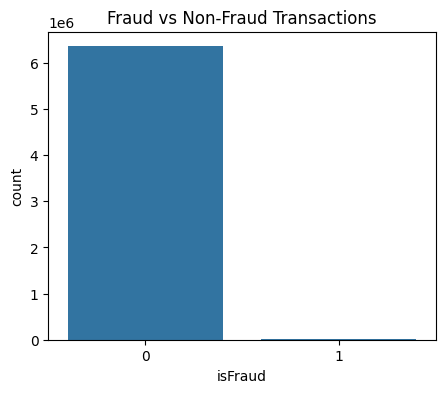

In [11]:
plt.figure(figsize=(5,4))
sns.countplot(x='isFraud', data=df)
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()


--- Amount Statistics by Fraud ---
             count          mean           std   min         25%        50%  \
isFraud                                                                       
0        6354407.0  1.781970e+05  5.962370e+05  0.01   13368.395   74684.72   
1           8213.0  1.467967e+06  2.404253e+06  0.00  127091.330  441423.44   

                75%          max  
isFraud                           
0         208364.76  92445516.64  
1        1517771.48  10000000.00  


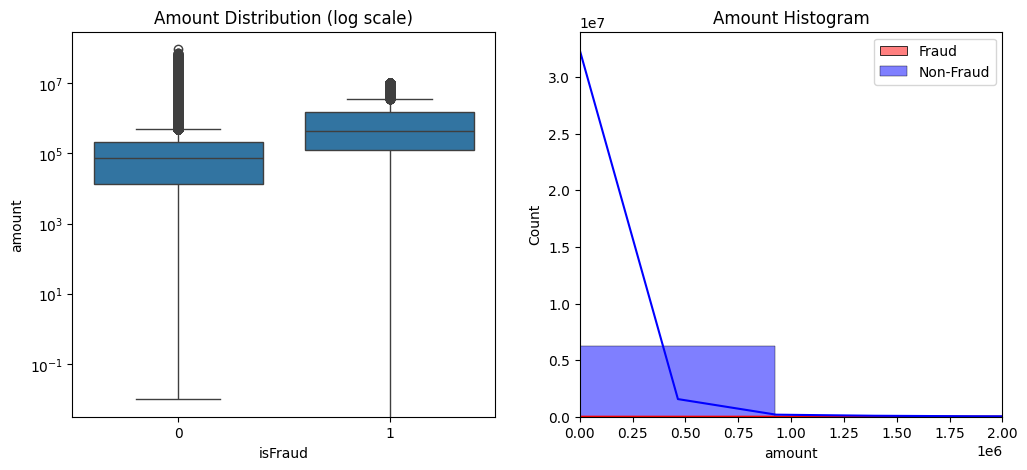

In [12]:
print("\n--- Amount Statistics by Fraud ---")
print(df.groupby('isFraud')['amount'].describe())

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x='isFraud', y='amount', data=df)
plt.yscale('log')
plt.title('Amount Distribution (log scale)')
plt.subplot(1,2,2)
sns.histplot(df[df['isFraud']==1]['amount'], bins=50, color='red', label='Fraud', kde=True)
sns.histplot(df[df['isFraud']==0]['amount'], bins=100, color='blue', label='Non-Fraud', kde=True, alpha=0.5)
plt.legend()
plt.title('Amount Histogram')
plt.xlim(0, 2e6)
plt.show()

In [13]:
print("\n--- Balance Analysis ---")
fraud_data = df[df['isFraud']==1]
print("Fraud cases where oldbalanceOrg == newbalanceOrig:", 
      (fraud_data['oldbalanceOrg'] == fraud_data['newbalanceOrig']).sum(), 
      "out of", len(fraud_data))
print("Fraud cases where oldbalanceDest == 0 before:", 
      (fraud_data['oldbalanceDest'] == 0).sum())


--- Balance Analysis ---
Fraud cases where oldbalanceOrg == newbalanceOrig: 57 out of 8213
Fraud cases where oldbalanceDest == 0 before: 5351


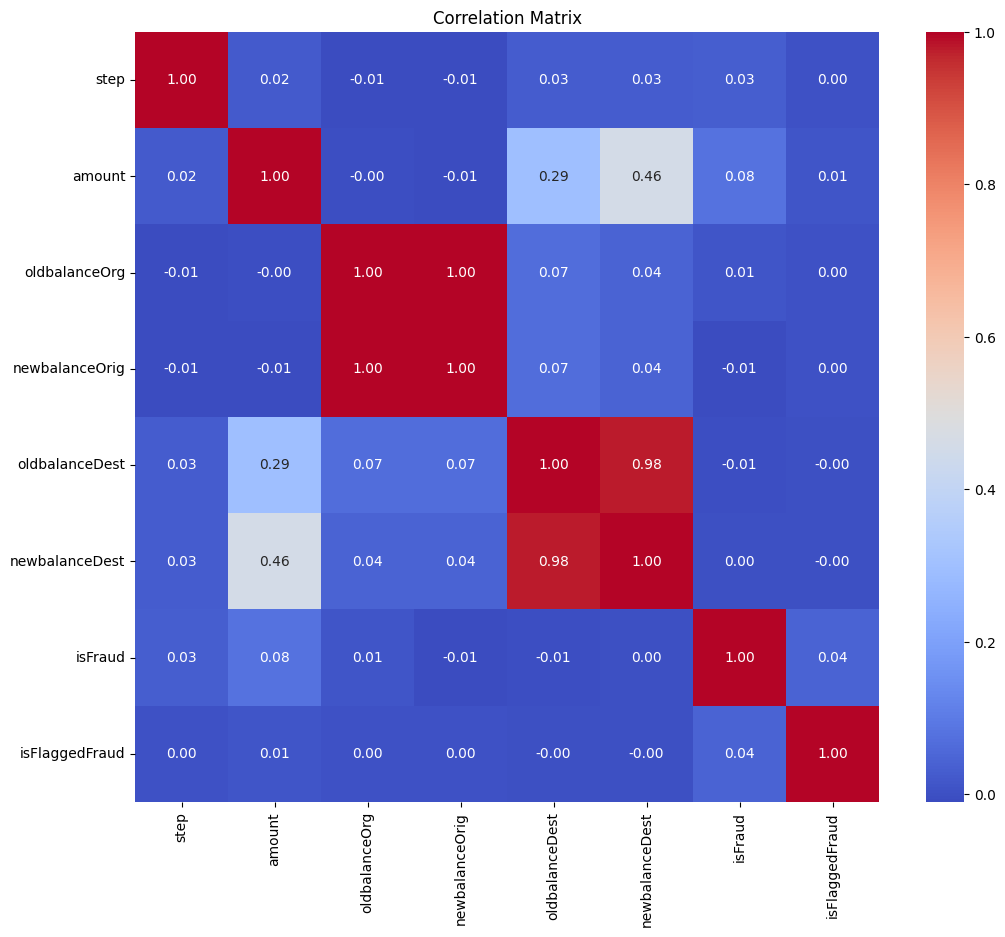

In [14]:
# Correlation matrix
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12,10))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [15]:
df["isFlaggedFraud"].value_counts()
# hm dekh sakte hain ki kitne transactions ko fraud ke roop mein flag kiya gaya hai aur kitne nahi kiya gaya hai.

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [16]:
df[("isFraud")].value_counts()
# hm dekh sakte hain ki kitne transactions fraud hain aur kitne nahi hain.

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [17]:
df[(df["type"]=="transfer")| (df["type"]=="payment")]["isFraud"].value_counts()
# hm dekh sakte hain ki transfer aur payment transactions mein kitne fraud hain aur kitne nahi hain.



Series([], Name: count, dtype: int64)

In [18]:
df = df.drop("isFlaggedFraud", axis=1)

In [19]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [20]:


# drop cash_in and cash_out or debit transactions
df = df[df["type"].isin(["TRANSFER", "PAYMENT"])]


In [21]:
df.shape

(2684404, 10)

In [22]:
df[df.duplicated()]
# duplicate rows ko check karna

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud


In [23]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [24]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...
6362610,742,TRANSFER,63416.99,C778071008,63416.99,0.00,C1812552860,0.0,0.0,1
6362612,743,TRANSFER,1258818.82,C1531301470,1258818.82,0.00,C1470998563,0.0,0.0,1
6362614,743,TRANSFER,339682.13,C2013999242,339682.13,0.00,C1850423904,0.0,0.0,1
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.0,0.0,1


In [74]:
# add random location fields during feature engineering (for demo purposes)
import random
locations = ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Kolkata', 'Pune', 'Jaipur']
# use numpy for faster sampling
import numpy as np

df['location_orig'] = np.random.choice(locations, size=len(df))
df['location_dest'] = np.random.choice(locations, size=len(df))

# one‑hot encode the new categorical columns and drop originals in one step
# this avoids manual concat/drop and keeps the dataframe tidy
df = pd.get_dummies(
    df,
    columns=['location_orig', 'location_dest'],
    prefix=['loc_orig', 'loc_dest']
)

# standard time-based features – make sure 'step' still exists when running
if 'step' in df.columns:
    df['hour'] = df['step'] % 24   # extract hour from step column
    df['is_night'] = (df['hour'] < 6).astype(int)  # night time flag
else:
    print("warning: 'step' column is missing; hour/is_night not created")
# Note: drop of 'step' happens later in the notebook, so execute this cell before that removal.


In [26]:
# --- Placeholder for future location features ---
# You would typically one-hot encode countries, cities, or IP zones.
# For now, we'll add a constant column as a placeholder. 
# In a real scenario, you'd merge this from another dataset.
df['location_match'] = 1  # Assume 1 if locations match, 0 if different
# Or create dummy columns for common locations
# df['location_IND'] = 0
# df['location_US'] = 0
# --- End Placeholder ---

In [27]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,location_match
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,1,1,1
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,1,1,1
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,1,1,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,1,1,1
5,1,PAYMENT,7817.71,C90045638,53860.0,46042.29,M573487274,0.0,0.0,0,1,1,1


In [28]:
# transaction amount features
df["amount_ratio"] = df["amount"] / (df["oldbalanceOrg"] + 1)  # +1 to avoid division by zero

In [29]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,location_match,amount_ratio
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,1,1,1,0.057834
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,1,1,1,0.087731
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,1,1,1,0.994505
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,1,1,1,0.280788
5,1,PAYMENT,7817.71,C90045638,53860.0,46042.29,M573487274,0.0,0.0,0,1,1,1,0.145146


In [30]:
df["sender_balance_change"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["receiver_balance_change"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [31]:
df[df["isFraud"]==1]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,location_match,amount_ratio,sender_balance_change,receiver_balance_change
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.0,0.0,1,1,1,1,0.994505,181.00,0.0
251,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.0,0.0,1,1,1,1,0.999644,2806.00,0.0
680,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.0,0.0,1,1,1,1,0.999950,20128.00,0.0
969,1,TRANSFER,1277212.77,C1334405552,1277212.77,0.0,C431687661,0.0,0.0,1,1,1,1,0.999999,1277212.77,0.0
1115,1,TRANSFER,35063.63,C1364127192,35063.63,0.0,C1136419747,0.0,0.0,1,1,1,1,0.999971,35063.63,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362610,742,TRANSFER,63416.99,C778071008,63416.99,0.0,C1812552860,0.0,0.0,1,22,0,1,0.999984,63416.99,0.0
6362612,743,TRANSFER,1258818.82,C1531301470,1258818.82,0.0,C1470998563,0.0,0.0,1,23,0,1,0.999999,1258818.82,0.0
6362614,743,TRANSFER,339682.13,C2013999242,339682.13,0.0,C1850423904,0.0,0.0,1,23,0,1,0.999997,339682.13,0.0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.0,0.0,1,23,0,1,1.000000,6311409.28,0.0


In [32]:
df["orig_balance_change"] = (df["oldbalanceOrg"]==0).astype(int)
df["dest_balance_zero"] = (df["oldbalanceDest"]==0).astype(int)

In [33]:
df.sample(4)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,location_match,amount_ratio,sender_balance_change,receiver_balance_change,orig_balance_change,dest_balance_zero
2146851,184,PAYMENT,33810.38,C118519161,630.0,0.00,M395034454,0.00,0.00,0,16,0,1,5.358222e+01,630.00,0.00,0,1
2513132,205,PAYMENT,15017.49,C1872079210,72049.0,57031.51,M839195271,0.00,0.00,0,13,0,1,2.084315e-01,15017.49,0.00,0,1
2226137,186,TRANSFER,1127066.35,C282460389,0.0,0.00,C392998111,1552052.78,2679119.13,0,18,0,1,1.127066e+06,0.00,1127066.35,1,0
6263030,612,PAYMENT,14756.79,C1245244461,0.0,0.00,M900419330,0.00,0.00,0,12,0,1,1.475679e+04,0.00,0.00,1,1


In [34]:
df[df["isFraud"]==1]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,location_match,amount_ratio,sender_balance_change,receiver_balance_change,orig_balance_change,dest_balance_zero
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.0,0.0,1,1,1,1,0.994505,181.00,0.0,0,1
251,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.0,0.0,1,1,1,1,0.999644,2806.00,0.0,0,1
680,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.0,0.0,1,1,1,1,0.999950,20128.00,0.0,0,1
969,1,TRANSFER,1277212.77,C1334405552,1277212.77,0.0,C431687661,0.0,0.0,1,1,1,1,0.999999,1277212.77,0.0,0,1
1115,1,TRANSFER,35063.63,C1364127192,35063.63,0.0,C1136419747,0.0,0.0,1,1,1,1,0.999971,35063.63,0.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362610,742,TRANSFER,63416.99,C778071008,63416.99,0.0,C1812552860,0.0,0.0,1,22,0,1,0.999984,63416.99,0.0,0,1
6362612,743,TRANSFER,1258818.82,C1531301470,1258818.82,0.0,C1470998563,0.0,0.0,1,23,0,1,0.999999,1258818.82,0.0,0,1
6362614,743,TRANSFER,339682.13,C2013999242,339682.13,0.0,C1850423904,0.0,0.0,1,23,0,1,0.999997,339682.13,0.0,0,1
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.0,0.0,1,23,0,1,1.000000,6311409.28,0.0,0,1


In [38]:
# ===== FAST VERSION (using bins) =====
# Create a column for 6-hour block
df['step_bin'] = df['step'] // 6  # 0,1,2,... (har 6 step ka ek bin)

# Count transactions per (nameDest, step_bin) using transform
df['transactions_last_6hrs_dest'] = df.groupby(['nameDest', 'step_bin'])['step'].transform('count') - 1

# Same for nameOrig
df['transactions_last_6hrs_orig'] = df.groupby(['nameOrig', 'step_bin'])['step'].transform('count') - 1

# High frequency flag
df['high_freq_dest'] = (df['transactions_last_6hrs_dest'] > 5).astype(int)
df['high_freq_orig'] = (df['transactions_last_6hrs_orig'] > 5).astype(int)

# Drop temporary bin column
df.drop('step_bin', axis=1, inplace=True)

In [39]:
# convert categorical variable to numeric
dummies = pd.get_dummies(df["type"]).astype(int)
dummies.tail()

,PAYMENT,TRANSFER
2684399,1,0
2684400,1,0
2684401,1,0
2684402,1,0
2684403,1,0


In [40]:
df = pd.get_dummies(df, columns=["type"],drop_first=True)

In [41]:
df.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,...,dest_balance_zero,transactions_last_6hrs_dest_x,transactions_last_6hrs_dest_y,transactions_last_6hrs_orig_x,transactions_last_6hrs_dest,transactions_last_6hrs_orig_y,transactions_last_6hrs_orig,high_freq_dest,high_freq_orig,type_TRANSFER
0,217,3170.28,C1000001337,58089.0,54918.72,M216466820,0.00,0.00,0,1,...,1,1.0,1,1,0,1,0,0,0,False
1,46,8424.74,C1000001725,783.0,0.00,M1974356374,0.00,0.00,0,22,...,1,1.0,1,1,0,1,0,0,0,False
2,226,3228390.11,C1000005353,24996.0,0.00,C292963054,878327.64,4106717.75,0,10,...,0,3.0,1,1,0,1,0,0,0,True
3,380,3229333.12,C1000005749,0.0,0.00,C1247252665,9987425.74,13216758.86,0,20,...,0,1.0,1,1,0,1,0,0,0,True
4,300,4615.66,C1000006873,313.0,0.00,M1063351314,0.00,0.00,0,12,...,1,1.0,1,1,0,1,0,0,0,False


In [42]:
df["type_TRANSFER"] = df["type_TRANSFER"].astype(int)
df.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,...,dest_balance_zero,transactions_last_6hrs_dest_x,transactions_last_6hrs_dest_y,transactions_last_6hrs_orig_x,transactions_last_6hrs_dest,transactions_last_6hrs_orig_y,transactions_last_6hrs_orig,high_freq_dest,high_freq_orig,type_TRANSFER
0,217,3170.28,C1000001337,58089.0,54918.72,M216466820,0.00,0.00,0,1,...,1,1.0,1,1,0,1,0,0,0,0
1,46,8424.74,C1000001725,783.0,0.00,M1974356374,0.00,0.00,0,22,...,1,1.0,1,1,0,1,0,0,0,0
2,226,3228390.11,C1000005353,24996.0,0.00,C292963054,878327.64,4106717.75,0,10,...,0,3.0,1,1,0,1,0,0,0,1
3,380,3229333.12,C1000005749,0.0,0.00,C1247252665,9987425.74,13216758.86,0,20,...,0,1.0,1,1,0,1,0,0,0,1
4,300,4615.66,C1000006873,313.0,0.00,M1063351314,0.00,0.00,0,12,...,1,1.0,1,1,0,1,0,0,0,0


In [43]:
# dropping unnecessary columns
df.drop(["nameOrig","nameDest"],axis =1,inplace=True)


In [44]:
df.shape

(2684404, 24)

In [45]:
df.sample(10)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,location_match,...,dest_balance_zero,transactions_last_6hrs_dest_x,transactions_last_6hrs_dest_y,transactions_last_6hrs_orig_x,transactions_last_6hrs_dest,transactions_last_6hrs_orig_y,transactions_last_6hrs_orig,high_freq_dest,high_freq_orig,type_TRANSFER
1125350,205,98204.99,0.0,0.00,8695654.59,8793859.57,0,13,0,1,...,0,6.0,2,1,1,1,0,0,0,1
2062960,360,744.54,31400.0,30655.46,0.00,0.00,0,0,1,1,...,1,1.0,1,1,0,1,0,0,0,0
2485939,329,300138.43,10892.0,0.00,82453.82,382592.24,0,17,0,1,...,0,1.0,1,1,0,1,0,0,0,1
2154420,211,1903740.03,0.0,0.00,3565881.71,5469621.74,0,19,0,1,...,0,4.0,1,1,0,1,0,0,0,1
1472773,349,12548.06,0.0,0.00,0.00,0.00,0,13,0,1,...,1,1.0,1,1,0,1,0,0,0,0
272252,40,8732.10,0.0,0.00,0.00,0.00,0,16,0,1,...,1,1.0,1,1,0,1,0,0,0,0
557520,348,1181.86,23996.0,22814.14,0.00,0.00,0,12,0,1,...,1,1.0,1,1,0,1,0,0,0,0
1815808,233,61566.86,0.0,0.00,0.00,0.00,0,17,0,1,...,1,1.0,1,1,0,1,0,0,0,0
973431,258,9363.12,0.0,0.00,0.00,0.00,0,18,0,1,...,1,1.0,1,1,0,1,0,0,0,0
1091760,283,4761.37,210375.0,205613.63,0.00,0.00,0,19,0,1,...,1,1.0,1,1,0,1,0,0,0,0


In [46]:
# independent and dependent features
df.drop(columns=["step"],inplace=True)

In [47]:
x = df.drop("isFraud" , axis=1)
y = df["isFraud"]

In [48]:
x

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,hour,is_night,location_match,amount_ratio,sender_balance_change,...,dest_balance_zero,transactions_last_6hrs_dest_x,transactions_last_6hrs_dest_y,transactions_last_6hrs_orig_x,transactions_last_6hrs_dest,transactions_last_6hrs_orig_y,transactions_last_6hrs_orig,high_freq_dest,high_freq_orig,type_TRANSFER
0,3170.28,58089.00,54918.72,0.00,0.00,1,1,1,5.457531e-02,3170.28,...,1,1.0,1,1,0,1,0,0,0,0
1,8424.74,783.00,0.00,0.00,0.00,22,0,1,1.074584e+01,783.00,...,1,1.0,1,1,0,1,0,0,0,0
2,3228390.11,24996.00,0.00,878327.64,4106717.75,10,0,1,1.291511e+02,24996.00,...,0,3.0,1,1,0,1,0,0,0,1
3,3229333.12,0.00,0.00,9987425.74,13216758.86,20,0,1,3.229333e+06,0.00,...,0,1.0,1,1,0,1,0,0,0,1
4,4615.66,313.00,0.00,0.00,0.00,12,0,1,1.469955e+01,313.00,...,1,1.0,1,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2684399,61919.08,86524.98,24605.90,0.00,0.00,19,0,1,7.156126e-01,61919.08,...,1,1.0,1,1,0,1,0,0,0,0
2684400,13211.14,0.00,0.00,0.00,0.00,17,0,1,1.321114e+04,0.00,...,1,1.0,1,1,0,1,0,0,0,0
2684401,4538.54,0.00,0.00,0.00,0.00,15,0,1,4.538540e+03,0.00,...,1,1.0,1,1,0,1,0,0,0,0
2684402,26585.43,0.00,0.00,0.00,0.00,19,0,1,2.658543e+04,0.00,...,1,1.0,1,1,0,1,0,0,0,0


In [49]:
y


0          0
1          0
2          0
3          0
4          0
          ..
2684399    0
2684400    0
2684401    0
2684402    0
2684403    0
Name: isFraud, Length: 2684404, dtype: int64

In [50]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25, random_state=42, shuffle=True)


In [51]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape


((2013303, 22), (2013303,), (671101, 22), (671101,))

In [52]:
# model training using logistic regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

import joblib
joblib.dump(scaler, "scaler_latest.pkl")



['scaler_latest.pkl']

In [53]:
x_train_scaled


array([[-0.19015506, -0.20644505, -0.24536848, ..., -0.02536017,
         0.        , -0.49748217],
       [-0.20458885, -0.06034418, -0.03041538, ..., -0.02536017,
         0.        , -0.49748217],
       [-0.19725367, -0.25014403, -0.24536848, ..., -0.02536017,
         0.        , -0.49748217],
       ...,
       [-0.19956294, -0.11064566, -0.114859  , ..., -0.02536017,
         0.        , -0.49748217],
       [-0.19533104, -0.25014403, -0.24536848, ..., -0.02536017,
         0.        , -0.49748217],
       [ 0.66732073, -0.25014403, -0.24536848, ..., -0.02536017,
         0.        ,  2.01012228]], shape=(2013303, 22))

In [54]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=10000)

In [55]:
lr.fit(x_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [56]:
y_pred1 = lr.predict(x_test_scaled)
y_pred1

array([0, 0, 0, ..., 0, 0, 0], shape=(671101,))

In [57]:
# check the classification report
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
acc_score =accuracy_score(y_test, y_pred1)
print(f"accuracy score: {acc_score}")
print()
print("confusion matrix:")
print(confusion_matrix(y_test, y_pred1))
print()
print("classification report:")
print(classification_report(y_test, y_pred1))


accuracy score: 0.9995589337521475

confusion matrix:
[[670051      5]
 [   291    754]]

classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    670056
           1       0.99      0.72      0.84      1045

    accuracy                           1.00    671101
   macro avg       1.00      0.86      0.92    671101
weighted avg       1.00      1.00      1.00    671101



In [58]:
# decision tree classifier
from sklearn.tree import DecisionTreeClassifier


In [59]:
dt = DecisionTreeClassifier(max_depth=5,class_weight={0:1, 1:10})

In [60]:
dt.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [61]:
# visualize the decision tree
dt.get_depth()


5

In [62]:
y_pred =dt.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(671101,))

In [63]:
# check the classification report
from sklearn.metrics import accuracy_score,confusion_matrix , classification_report


In [64]:
acc_score = accuracy_score(y_test, y_pred)
print(f"accuracy_score: {acc_score}")
print()
print("confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print("classification report:")
print(classification_report(y_test, y_pred))

accuracy_score: 0.999654299427359

confusion matrix:
[[669831    225]
 [     7   1038]]

classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    670056
           1       0.82      0.99      0.90      1045

    accuracy                           1.00    671101
   macro avg       0.91      1.00      0.95    671101
weighted avg       1.00      1.00      1.00    671101



In [ ]:
# try random forest classifier since decision tree is overfitting the data
# training can be slow on the full dataset; we enable parallel jobs and
# you can also reduce n_estimators for quicker experimentation
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight={0:1, 1:10},
    random_state=42,
    n_jobs=-1  # use all CPU cores for faster fitting
)


In [67]:
rf_model.fit(x_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [75]:
from sklearn.ensemble import IsolationForest

# Isolation Forest train karo
iso_forest = IsolationForest(contamination=0.01, random_state=42)
iso_forest.fit(x_train_scaled)  # scaled features use karo

# Save karo
joblib.dump(iso_forest, 'isolation_forest.pkl')

['isolation_forest.pkl']

In [ ]:
y_pred = rf_model.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(671101,))

In [68]:
# accuracy of model along with classification report
acc_score = accuracy_score(y_test, y_pred)*100
print(f"accuracy score: {acc_score}%")
print()
print("confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print("classification report:")
print(classification_report(y_test, y_pred))



accuracy score: 99.9654299427359%

confusion matrix:
[[669831    225]
 [     7   1038]]

classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    670056
           1       0.82      0.99      0.90      1045

    accuracy                           1.00    671101
   macro avg       0.91      1.00      0.95    671101
weighted avg       1.00      1.00      1.00    671101



In [69]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model" , RandomForestClassifier(n_estimators=100, class_weight={0:1, 1:10},random_state=42))
])

pipe.fit(x_train, y_train)

# evaluate the model
pred_test = pipe.predict(x_test)
print(classification_report(y_test, pred_test))

# save the pipeline
joblib.dump(pipe, "credit_card_fraud_model.pkl")
print("Pipeline saved successfully!")


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    670056
           1       1.00      0.99      1.00      1045

    accuracy                           1.00    671101
   macro avg       1.00      1.00      1.00    671101
weighted avg       1.00      1.00      1.00    671101

Pipeline saved successfully!


In [71]:
# quickly show type value counts
# print(df['type'].value_counts())
